Calculates the performance characteristics of a trapezoidal, 3D wing based on input parameters.

Uses a custom spanwise-loading model for the trapezoidal planform instead of assuming an elliptical lift distribution.

In [81]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Root airfoil=xf-fx63137sm.csv; tip airfoil=xf-s7055.csv; tip washout=0.00 deg
Using measured polar data over the shared alpha range [-8.50, 17.00] deg
c_r=0.36 m, taper=0.40: alpha=-5° -> CL=0.0735, L/D=3.254, L=5.63 N; alpha=10° -> CL=1.4618, L/D=26.057, L=111.92 N
c_r=0.28 m, taper=0.80: alpha=-5° -> CL=0.0608, L/D=2.716, L=4.65 N; alpha=10° -> CL=1.4257, L/D=26.248, L=109.15 N
c_r=0.25 m, taper=1.00: alpha=-5° -> CL=0.0562, L/D=2.517, L=4.30 N; alpha=10° -> CL=1.4083, L/D=25.879, L=107.83 N
Target lift 70.0 N: c_r=0.36 m, taper=0.40, alpha=3.074 deg, CL=0.9143, CD=0.0273, L/D=33.515
Target lift 70.0 N: c_r=0.28 m, taper=0.80, alpha=3.370 deg, CL=0.9143, CD=0.0267, L/D=34.237
Target lift 70.0 N: c_r=0.25 m, taper=1.00, alpha=3.508 deg, CL=0.9143, CD=0.0268, L/D=34.056


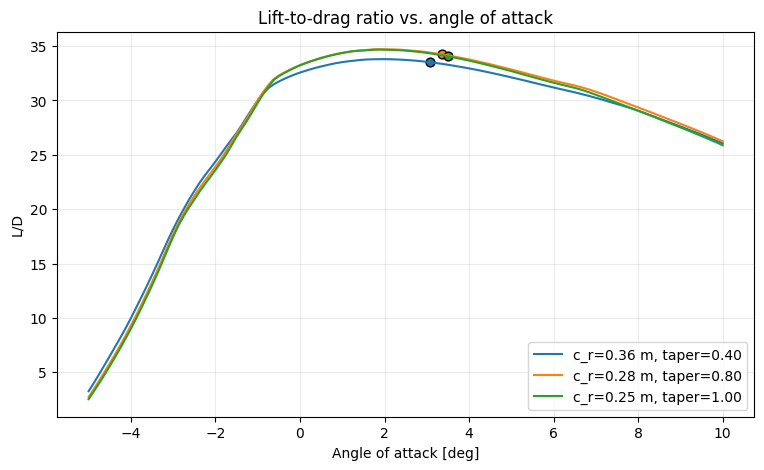

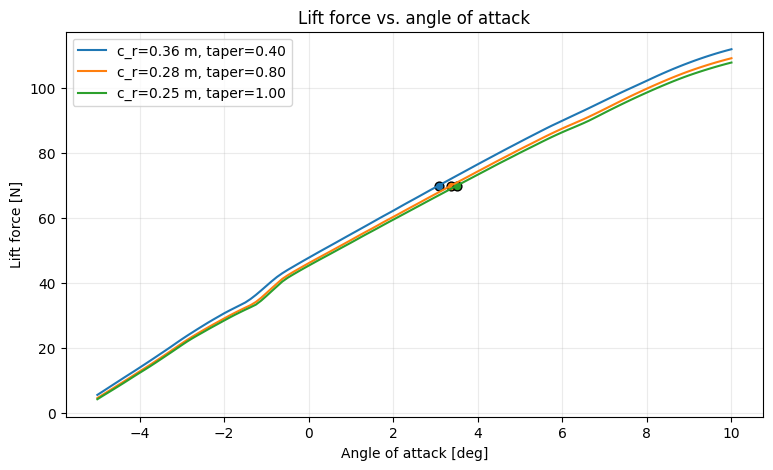

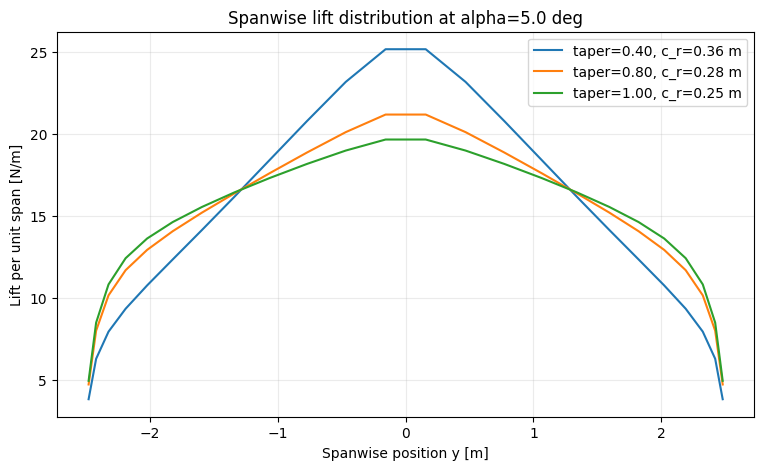

In [82]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import af_2d

# User-selectable taper ratios; root chord is derived to keep area constant.
taper_values = [0.4, 0.8, 1.0]
alpha_vals_deg = np.linspace(-5.0, 10.0, 121)
lift_distribution_alpha_deg = 5.0

# Select polar files at comparable Reynolds and Mach conditions when possible.
airfoil_data_dir_candidates = [
    Path.cwd() / "airfoil-performance",
    Path("airfoil-performance"),
]
airfoil_data_dir = next(
    (path for path in airfoil_data_dir_candidates if path.is_dir()),
    airfoil_data_dir_candidates[0],
)
root_airfoil_name = "xf-fx63137sm.csv"
tip_airfoil_name = "xf-s7055.csv"
root_airfoil_file = airfoil_data_dir / root_airfoil_name
tip_airfoil_file = airfoil_data_dir / tip_airfoil_name
missing_airfoil_files = [
    str(path) for path in (root_airfoil_file, tip_airfoil_file) if not path.exists()
]
if missing_airfoil_files:
    raise FileNotFoundError(f"Airfoil data not found: {', '.join(missing_airfoil_files)}")

tip_washout_deg = 0.0  # Positive values reduce incidence linearly from root to tip.

rho = 1.225  # kg/m^3
V = 10.0     # m/s
b = 5.0      # wingspan, m
wing_area_m2 = 1.25  # Fixed reference area: c_r=0.25 m and taper=1 at this span.
n_modes = 24


def load_airfoil_polar(file_path):
    """Load measured Cl and Cd polar curves for one airfoil."""
    return af_2d.get_polar_data(file_path)


root_airfoil_polar = load_airfoil_polar(root_airfoil_file)
tip_airfoil_polar = load_airfoil_polar(tip_airfoil_file)
polar_alpha_min_deg = max(root_airfoil_polar["alpha_deg"][0], tip_airfoil_polar["alpha_deg"][0])
polar_alpha_max_deg = min(root_airfoil_polar["alpha_deg"][-1], tip_airfoil_polar["alpha_deg"][-1])
polar_margin_deg = 0.25
target_alpha_min_deg = max(
    -5.0,
    polar_alpha_min_deg + max(tip_washout_deg, 0.0) + polar_margin_deg,
)
target_alpha_max_deg = min(
    10.0,
    polar_alpha_max_deg - max(-tip_washout_deg, 0.0) - polar_margin_deg,
)
if target_alpha_min_deg >= target_alpha_max_deg:
    raise ValueError("The selected washout leaves no valid target-lift range within the polar data.")


def interpolate_spanwise_polar(alpha_deg, span_fraction, coefficient):
    """Sample each measured polar at local alpha, then blend root to tip."""
    root_values = np.interp(alpha_deg, root_airfoil_polar["alpha_deg"], root_airfoil_polar[coefficient])
    tip_values = np.interp(alpha_deg, tip_airfoil_polar["alpha_deg"], tip_airfoil_polar[coefficient])
    return root_values + span_fraction * (tip_values - root_values)


def solve_wing_case(alpha_deg, c_r, lambda_t, initial_coefficients=None):
    """Return integrated performance and spanwise lift for one wing case."""
    alpha = np.deg2rad(alpha_deg)
    S = 0.5 * b * c_r * (1.0 + lambda_t)
    AR = b**2 / S

    theta = np.pi * np.arange(1, n_modes + 1) / (n_modes + 1)
    y = -(b / 2.0) * np.cos(theta)
    eta = 2.0 * y / b
    span_fraction = np.abs(eta)
    chord = c_r * (1.0 - (1.0 - lambda_t) * span_fraction)
    local_alpha = alpha - np.deg2rad(tip_washout_deg) * span_fraction

    mode_numbers = np.arange(1, n_modes + 1)
    sine_modes = np.sin(np.outer(mode_numbers, theta))

    def circulation_residual(coefficients):
        spanwise_load = sine_modes @ coefficients
        cl_from_circulation = 4.0 * b * spanwise_load / chord
        induced_alpha = (sine_modes.T @ (mode_numbers * coefficients)) / np.sin(theta)
        effective_alpha_deg = np.rad2deg(local_alpha - induced_alpha)
        bounded_alpha_deg = np.clip(effective_alpha_deg, polar_alpha_min_deg, polar_alpha_max_deg)
        section_cl = interpolate_spanwise_polar(bounded_alpha_deg, span_fraction, "cl")
        return cl_from_circulation - section_cl

    if initial_coefficients is None:
        initial_coefficients = np.zeros(n_modes)
    solution = least_squares(
        circulation_residual,
        initial_coefficients,
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10,
        max_nfev=2000,
    )
    residual_error = np.linalg.norm(circulation_residual(solution.x), ord=np.inf)
    if not solution.success:
        raise RuntimeError(f"Lifting-line solve failed at alpha={alpha_deg:.3f} deg: {solution.message}")
    if residual_error > 1e-6:
        raise RuntimeError(f"Lifting-line residual is too large at alpha={alpha_deg:.3f} deg: {residual_error:.3g}")

    A = solution.x
    spanwise_load = sine_modes @ A
    cl_dist = 4.0 * b * spanwise_load / chord
    induced_alpha = (sine_modes.T @ (mode_numbers * A)) / np.sin(theta)
    effective_alpha_deg = np.rad2deg(local_alpha - induced_alpha)
    if np.any(effective_alpha_deg < polar_alpha_min_deg) or np.any(effective_alpha_deg > polar_alpha_max_deg):
        raise ValueError(
            f"Effective alpha at alpha={alpha_deg:.3f} deg falls outside the shared polar range "
            f"[{polar_alpha_min_deg:.2f}, {polar_alpha_max_deg:.2f}] deg. "
            "Adjust the angle-of-attack sweep or washout, or use polars with wider coverage."
        )

    cd_profile_span = interpolate_spanwise_polar(effective_alpha_deg, span_fraction, "cd")
    CL = (1.0 / S) * np.trapezoid(chord * cl_dist, y)
    CD_i = np.pi * AR * np.sum(mode_numbers * A**2)
    CD_profile = (1.0 / S) * np.trapezoid(chord * cd_profile_span, y)
    CD_total = CD_profile + CD_i
    L_over_D = CL / CD_total

    q = 0.5 * rho * V**2
    lift_per_span = q * chord * cl_dist
    lift_force = q * S * CL
    return {
        "alpha_deg": alpha_deg,
        "CL": CL,
        "CD_total": CD_total,
        "L_over_D": L_over_D,
        "lift_force": lift_force,
        "c_r": c_r,
        "lambda_t": lambda_t,
        "AR": AR,
        "S": S,
        "y_span_m": y,
        "cl_dist": cl_dist,
        "lift_per_span_N_m": lift_per_span,
        "fourier_coefficients": A,
    }


wing_cases = [
    (2.0 * wing_area_m2 / (b * (1.0 + lambda_t)), lambda_t)
    for lambda_t in taper_values
]

all_cases = []
for c_r, lambda_t in wing_cases:
    curve = []
    initial_coefficients = None
    for alpha_deg in alpha_vals_deg:
        result = solve_wing_case(alpha_deg, c_r, lambda_t, initial_coefficients)
        curve.append(result)
        initial_coefficients = result["fourier_coefficients"]
    all_cases.append(curve)


def initial_coefficients_for_case(alpha_deg, c_r, lambda_t):
    """Interpolate a nearby converged solution to seed another solve."""
    curve = next(
        case for case in all_cases
        if np.isclose(case[0]["c_r"], c_r) and np.isclose(case[0]["lambda_t"], lambda_t)
    )
    sample_alphas = np.array([result["alpha_deg"] for result in curve])
    sample_coefficients = np.stack([result["fourier_coefficients"] for result in curve])
    return np.array([
        np.interp(alpha_deg, sample_alphas, sample_coefficients[:, mode_index])
        for mode_index in range(n_modes)
    ])


def solve_for_target_lift(target_lift_N, c_r, lambda_t, alpha_min=target_alpha_min_deg, alpha_max=target_alpha_max_deg):
    """Find the angle of attack that yields a target lift force for a given wing."""
    lo = alpha_min
    hi = alpha_max
    lo_result = solve_wing_case(lo, c_r, lambda_t, initial_coefficients_for_case(lo, c_r, lambda_t))
    hi_result = solve_wing_case(hi, c_r, lambda_t, initial_coefficients_for_case(hi, c_r, lambda_t))
    f_lo = lo_result["lift_force"] - target_lift_N
    f_hi = hi_result["lift_force"] - target_lift_N

    # Return a marked result if the target is outside the selected angle bracket.
    if f_lo > 0.0 or f_hi < 0.0:
        lo_result["target_lift_N"] = target_lift_N
        lo_result["alpha_target_deg"] = np.nan
        return lo_result

    for _ in range(200):
        mid = 0.5 * (lo + hi)
        initial_guess = 0.5 * (lo_result["fourier_coefficients"] + hi_result["fourier_coefficients"])
        mid_result = solve_wing_case(mid, c_r, lambda_t, initial_guess)
        f_mid = mid_result["lift_force"] - target_lift_N
        if abs(f_mid) < 1e-6:
            break
        if f_mid > 0.0:
            hi = mid
            hi_result = mid_result
        else:
            lo = mid
            lo_result = mid_result

    alpha_target = mid
    mid_result["target_lift_N"] = target_lift_N
    mid_result["alpha_target_deg"] = alpha_target
    return mid_result


print(f"Root airfoil={root_airfoil_name}; tip airfoil={tip_airfoil_name}; tip washout={tip_washout_deg:.2f} deg")
print(f"Using measured polar data over the shared alpha range [{polar_alpha_min_deg:.2f}, {polar_alpha_max_deg:.2f}] deg")

# Print a quick summary for the first and last operating point in each case.
for case in all_cases:
    first = case[0]
    last = case[-1]
    print(f"c_r={first['c_r']:.2f} m, taper={first['lambda_t']:.2f}: "
          f"alpha=-5° -> CL={first['CL']:.4f}, L/D={first['L_over_D']:.3f}, L={first['lift_force']:.2f} N; "
          f"alpha=10° -> CL={last['CL']:.4f}, L/D={last['L_over_D']:.3f}, L={last['lift_force']:.2f} N")

# Find the efficiency when producing 70 N of lift.
target_lift_N = 70.0
target_results = []
for c_r, lambda_t in wing_cases:
    result = solve_for_target_lift(target_lift_N, c_r, lambda_t)
    if np.isfinite(result["alpha_target_deg"]):
        target_results.append(result)
        print(
            f"Target lift {target_lift_N:.1f} N: c_r={result['c_r']:.2f} m, taper={result['lambda_t']:.2f}, "
            f"alpha={result['alpha_target_deg']:.3f} deg, CL={result['CL']:.4f}, CD={result['CD_total']:.4f}, L/D={result['L_over_D']:.3f}"
        )
    else:
        print(
            f"Target lift {target_lift_N:.1f} N is not reachable in the selected alpha range: "
            f"c_r={result['c_r']:.2f} m, taper={result['lambda_t']:.2f}"
        )

# Plot L/D versus alpha.
fig1, ax1 = plt.subplots(figsize=(9, 5))
for case in all_cases:
    alpha = np.array([item["alpha_deg"] for item in case])
    l_over_d = np.array([item["L_over_D"] for item in case])
    label = f"c_r={case[0]['c_r']:.2f} m, taper={case[0]['lambda_t']:.2f}"
    ax1.plot(alpha, l_over_d, label=label)

for result in target_results:
    ax1.scatter(result["alpha_target_deg"], result["L_over_D"], s=40, marker="o", edgecolors="k")

ax1.set_title("Lift-to-drag ratio vs. angle of attack")
ax1.set_xlabel("Angle of attack [deg]")
ax1.set_ylabel("L/D")
ax1.grid(True, alpha=0.25)
ax1.legend(loc="best")

# Plot lift force versus alpha.
fig2, ax2 = plt.subplots(figsize=(9, 5))
for case in all_cases:
    alpha = np.array([item["alpha_deg"] for item in case])
    lift_force = np.array([item["lift_force"] for item in case])
    label = f"c_r={case[0]['c_r']:.2f} m, taper={case[0]['lambda_t']:.2f}"
    ax2.plot(alpha, lift_force, label=label)

for result in target_results:
    ax2.scatter(result["alpha_target_deg"], result["lift_force"], s=40, marker="o", edgecolors="k")

ax2.set_title("Lift force vs. angle of attack")
ax2.set_xlabel("Angle of attack [deg]")
ax2.set_ylabel("Lift force [N]")
ax2.grid(True, alpha=0.25)
ax2.legend(loc="best")

# Plot lift per unit span at the selected angle of attack.
fig3, ax3 = plt.subplots(figsize=(9, 5))
for c_r, lambda_t in wing_cases:
    distribution = solve_wing_case(lift_distribution_alpha_deg, c_r, lambda_t)
    label = f"taper={lambda_t:.2f}, c_r={c_r:.2f} m"
    ax3.plot(
        distribution["y_span_m"],
        distribution["lift_per_span_N_m"],
        label=label,
    )

ax3.set_title(f"Spanwise lift distribution at alpha={lift_distribution_alpha_deg:.1f} deg")
ax3.set_xlabel("Spanwise position y [m]")
ax3.set_ylabel("Lift per unit span [N/m]")
ax3.grid(True, alpha=0.25)
ax3.legend(loc="best")

plt.show()